In [2]:
import sys, os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



#sistemare il warning di LightGBM fa creare warning a tutti gli altri modelli addestrati senza
#feature name, quindi meglio ingorarli
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'stellar_classification')))
import stellar_classification as sc
from sklearn.metrics import accuracy_score
from stellar_classification.models.trees import SimpleRandomForest

In [3]:
#importo i dati 

data_path = '../stellar_classification/stellar_classification/data/star_classification.csv'
star = pd.read_csv(data_path)

# -------- Color indexes ----------
star["u_g"] = star["u"] - star["g"]
star["g_r"] = star["g"] - star["r"]
star["r_i"] = star["r"] - star["i"]
star["i_z"] = star["i"] - star["z"]

X_train, X_val, X_test, y_train, y_val, y_test, label_encoder, scaler, feature_names = sc.prepare_splits(
    star, target_col='class', test_size=0.2, val_ratio=0.25,
    random_state=42, apply_outlier_removal=True
)
class_names = list(label_encoder.classes_)

Outliers removed: 8,715 rows  (91,285 remain)


In [4]:
#train su random forest ed extra trees
models = sc.train_trees_with_tuning(X_train, y_train, X_val, y_val, n_iter=5, cv=3)
rf_model = models['Random Forest']
et_model = models['Extra Trees']

Random Forest best params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_samples': None, 'max_features': 0.5, 'max_depth': 20}
  [Train] Acc=98.68%  F1=0.9868
  [Val] Acc=90.45%  F1=0.8781
Extra Trees best params: {'n_estimators': 150, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
  [Train] Acc=93.40%  F1=0.9340
  [Val] Acc=89.84%  F1=0.8703


In [5]:
#evaluate test set
rf_metrics = sc.evaluate_test_set(y_test, rf_model.predict(X_test), 'Random Forest')
et_metrics = sc.evaluate_test_set(y_test, et_model.predict(X_test), 'Extra Trees')

sc.print_metrics(rf_metrics)
sc.print_metrics(et_metrics)


Random Forest:
  Accuracy  : 90.70%
  Precision: 0.8790
  Recall   : 0.8846
  F1       : 0.8813
  Confusion Matrix:
[[10175   348   258]
 [  217  3097   234]
 [  278   362  3288]]

Extra Trees:
  Accuracy  : 89.87%
  Precision: 0.8696
  Recall   : 0.8748
  F1       : 0.8707
  Confusion Matrix:
[[10124   380   277]
 [  213  3149   186]
 [  327   467  3134]]


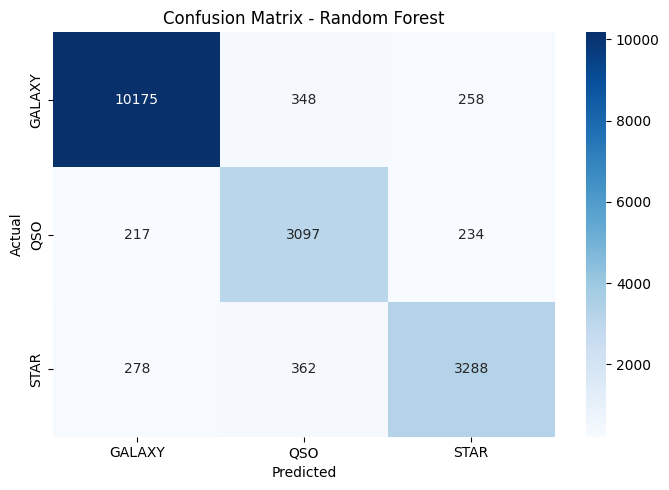

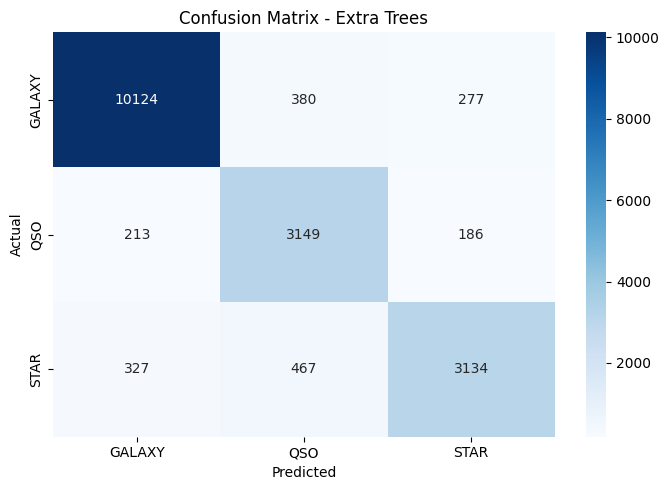

In [6]:
#matrici di confusione per i due modelli 

sc.plot_confusion_matrix(rf_metrics['confusion_matrix'], class_names=class_names,
                         title='Confusion Matrix - Random Forest')
sc.plot_confusion_matrix(et_metrics['confusion_matrix'], class_names=class_names,
                         title='Confusion Matrix - Extra Trees')

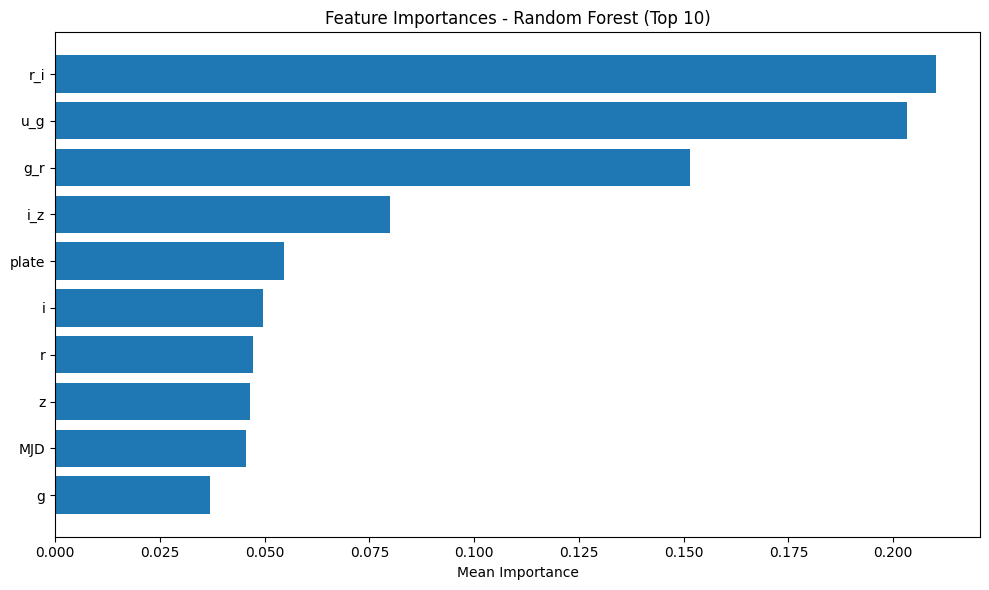

Feature importance score: 
 r_i      0.210192
u_g      0.203235
g_r      0.151383
i_z      0.079903
plate    0.054670
i        0.049575
r        0.047186
z        0.046471
MJD      0.045580
g        0.036877
u        0.031005
alpha    0.022023
delta    0.021899
dtype: float64


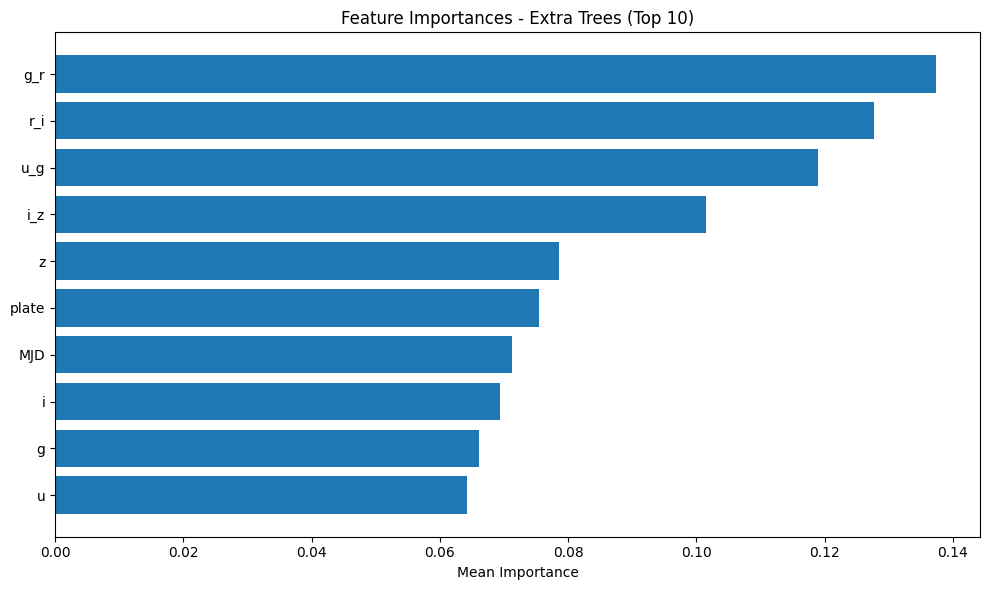

Feature importance score: 
 g_r      0.137370
r_i      0.127698
u_g      0.118945
i_z      0.101486
z        0.078569
plate    0.075405
MJD      0.071245
i        0.069432
g        0.066077
u        0.064211
r        0.051732
alpha    0.021954
delta    0.015876
dtype: float64


In [14]:
#faccio la fetaure importance interna alle random forest e extra trees

for name, model in [('Random Forest', rf_model), ('Extra Trees', et_model)]:
    imp = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
    sc.plot_permutation_importance(imp, top_n=10, title=f'Feature Importances - {name}')
    print( 'Feature importance score: \n', imp)

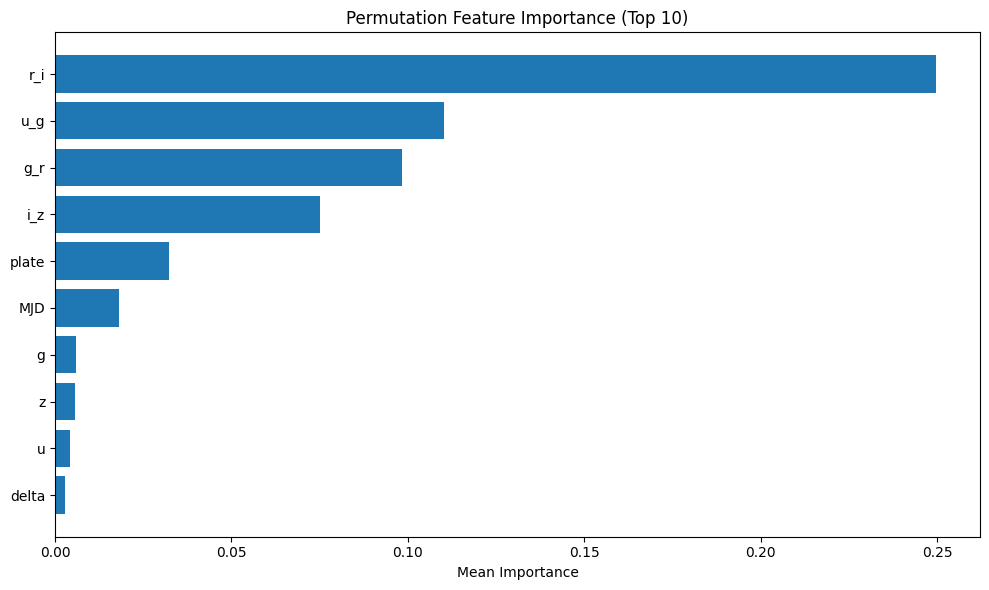

Feature Importance Scores of Random Forest:
r_i: 0.2497
u_g: 0.1102
g_r: 0.0984
i_z: 0.0752
plate: 0.0322
MJD: 0.0181
g: 0.0059
z: 0.0056
u: 0.0042
delta: 0.0028
i: 0.0027
r: 0.0019
alpha: 0.0015


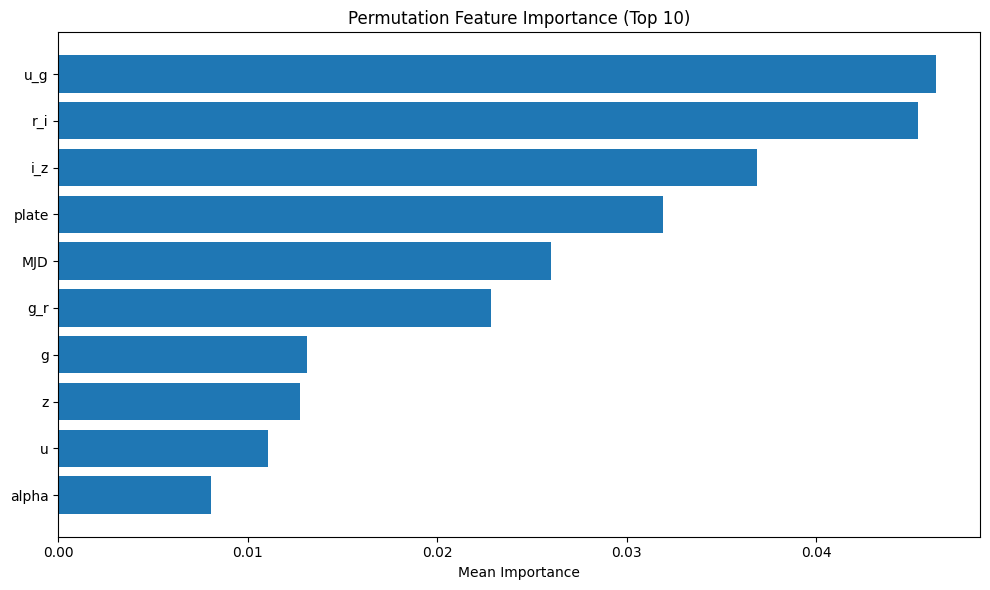

Feature Importance Scores of Extra Trees:
u_g: 0.0463
r_i: 0.0454
i_z: 0.0369
plate: 0.0319
MJD: 0.0260
g_r: 0.0228
g: 0.0131
z: 0.0127
u: 0.0110
alpha: 0.0081
i: 0.0068
delta: 0.0060
r: 0.0039


In [13]:
# Feature Importance (using permutation importance on the Voting Classifier) con le cose del prof 

for name, model in [('Random Forest', rf_model), ('Extra Trees', et_model)]:
    imp = sc.compute_permutation_importance(model, X_test, y_test, feature_names=feature_names)
    sc.plot_permutation_importance(imp, top_n=10)

    print(f'Feature Importance Scores of {name}:')
    for feat, val in imp.items():
        print(f"{feat}: {val:.4f}")

In [19]:
import importlib, sys

to_remove = [k for k in sys.modules if 'stellar_classification' in k]
for k in to_remove:
    del sys.modules[k]

import stellar_classification as sc

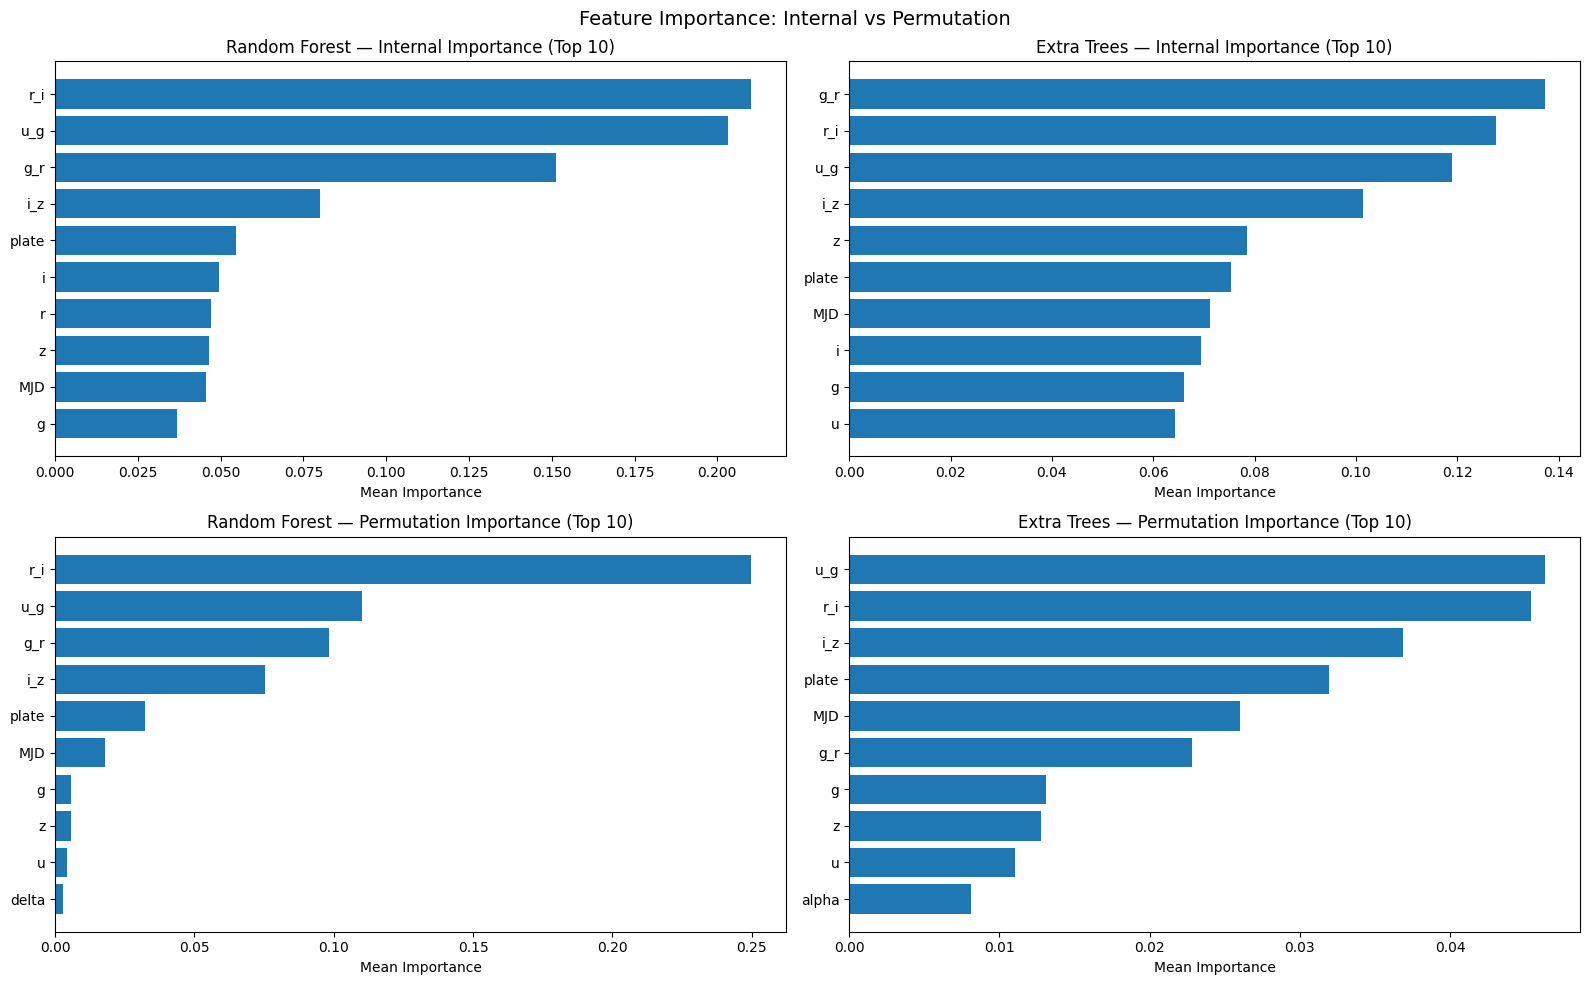

In [20]:
# Feature Importance: confronto tra metodo interno e permutation

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Feature Importance: Internal vs Permutation', fontsize=14)

for col, (name, model) in enumerate([('Random Forest', rf_model), 
                                      ('Extra Trees', et_model)]):
    # -- interno (training-based)
    imp_internal = pd.Series(model.feature_importances_, 
                             index=feature_names).sort_values(ascending=False)
    sc.plot_permutation_importance(imp_internal, top_n=10, title=f'{name} — Internal Importance',
                                   ax=axes[0, col] )
    

    # -- permutation (test-based)
    imp_perm = sc.compute_permutation_importance(model, X_test, y_test, 
                                                  feature_names=feature_names)
    imp_perm_series = sc.plot_permutation_importance(imp_perm, top_n=10,
                                                    title=f'{name} — Permutation Importance',
                                   ax=axes[1, col])
   
plt.tight_layout()
plt.show()

## Mini analisi 

### Cosa concordano i due metodi
I due metodi concordano sulle 4 feature dominanti (`r_i`, `u_g`, `g_r`, `i_z`), 
le quali compaiono in cima a tutti e 4 i grafici. Queste sono indici di colore 
fotometrico — differenze di magnitudine tra bande adiacenti del sistema SDSS — 
e rappresentano la grandezza fisica più discriminante per separare stelle, 
galassie e quasar.

### ET e RF divergono (internal importance) 
RF concentra il peso principalmente su `r_i` (~0.21), mentre ET ha come 
feature più importante `g_r` (~0.14), distribuendo il peso in modo più 
uniforme tra le prime quattro feature. Questo è coerente con la natura 
dei due algoritmi: RF cerca lo split ottimale ad ogni nodo, tendendo a 
favorire sempre le stesse feature; ET usa split casuali, distribuendo 
naturalmente il contributo tra più feature.

### ET e RF divergono (permutation importance) 
RF concentra nuovamente il peso su `r_i` (~0.25), confermando che è la 
feature più discriminante sul test set. Per ET invece emerge `u_g` come 
dominante, seguita da `r_i` e `i_z` con valori simili — suggerendo che 
ET sfrutta un insieme di feature leggermente diverso per generalizzare.

### Perché questa differenza tra i due metodi per ET?
Nell'importance interna ET assegna il peso massimo a `g_r`, mentre nella 
permutation importance emerge `u_g`. Questo indica che `g_r` viene usata 
frequentemente durante il training (molti split), ma quando la si mescola 
sul test set l'accuracy non cala drasticamente quanto per `u_g`. 
In altre parole, `u_g` è più *indispensabile* per la classificazione finale, 
mentre `g_r` è più *utilizzata* ma parzialmente ridondante con altre feature.

### plate e MJD 
Entrambi i modelli assegnano importanza non trascurabile a `plate` e `MJD`, 
che sono identificatori osservativi del survey SDSS, non grandezze fisiche 
intrinseche degli oggetti. La loro importanza suggerisce che i modelli 
hanno imparato correlazioni legate alla strategia di osservazione, 
non alle proprietà fisiche degli oggetti celesti. Questo è un limite 
del classificatore: funzionerebbe peggio su dati provenienti da un 
survey diverso da SDSS.